# Problem Title - Library Mode
Issue: #<1>

## 1. Setup and Imports
Import only the required ML library tools and keep setup minimal and reproducible.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, cross_val_score

## 2. Load and Inspect Data
Load dataset.csv and verify target column, feature types, and basic data quality checks.

In [2]:
df = pd.read_csv("../dataset.csv")
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,28,Private,319768,Masters,14,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,France,>50K
1,60,Private,120067,9th,5,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,45,United-States,<=50K
2,43,Private,211517,Some-college,10,Never-married,Adm-clerical,Not-in-family,White,Male,0,1669,45,United-States,<=50K.
3,35,State-gov,210866,HS-grad,9,Married-civ-spouse,Other-service,Husband,White,Male,0,0,40,United-States,<=50K.
4,36,Private,320811,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,>50K


In [3]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000
mean,38.526600,1.897329e+05,10.114200,1143.930700,91.012900,40.915700
std,13.184221,1.052897e+05,2.551472,7465.098891,410.644104,12.028253
min,17.000000,1.930200e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175670e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.786650e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.379258e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.268339e+06,16.000000,99999.000000,3770.000000,99.000000


In [4]:
df.isnull().sum().sort_values(ascending=False)
#Data is very clean, as can be seen in the output

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

hists+kde below


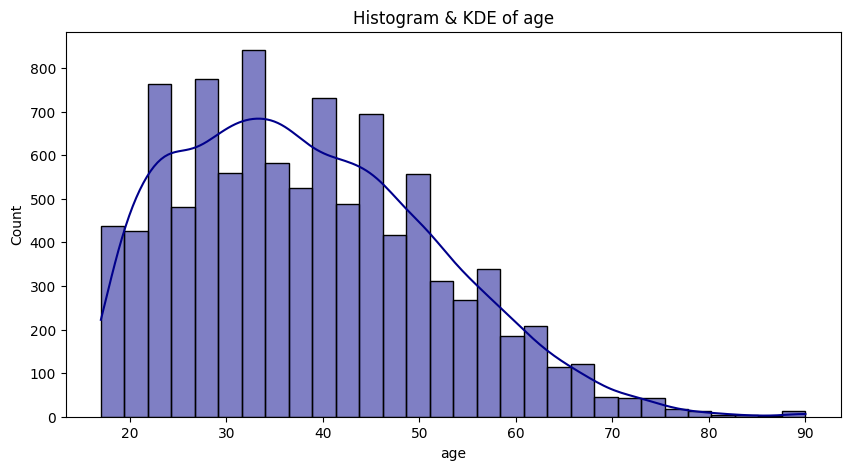

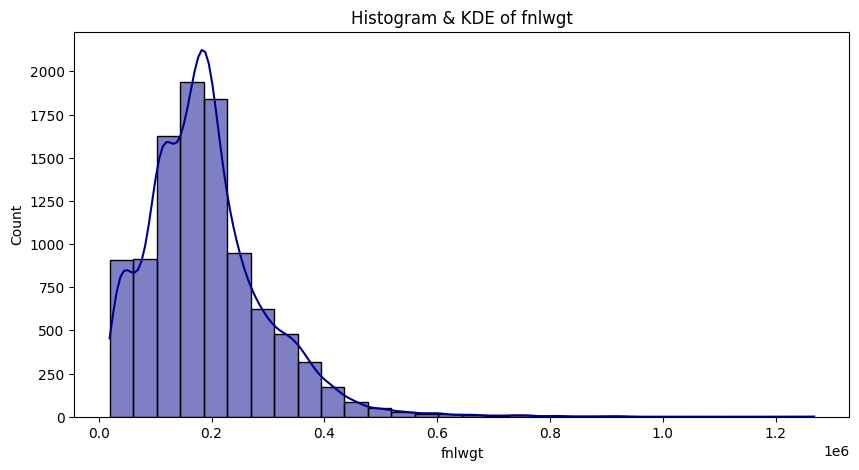

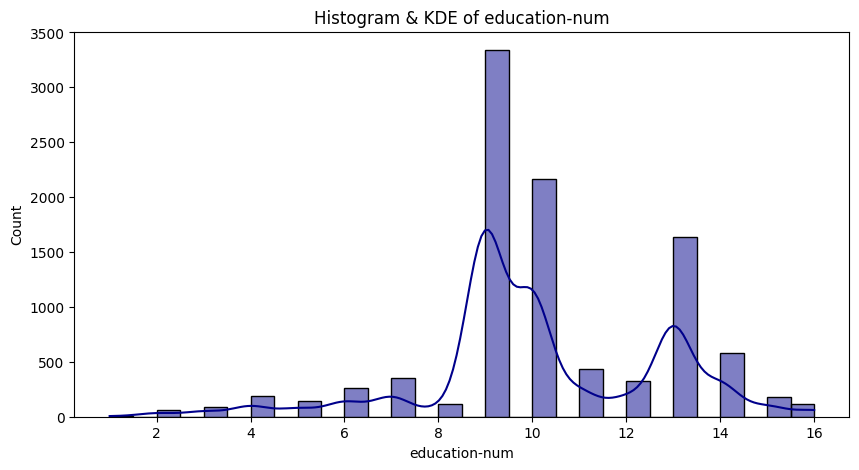

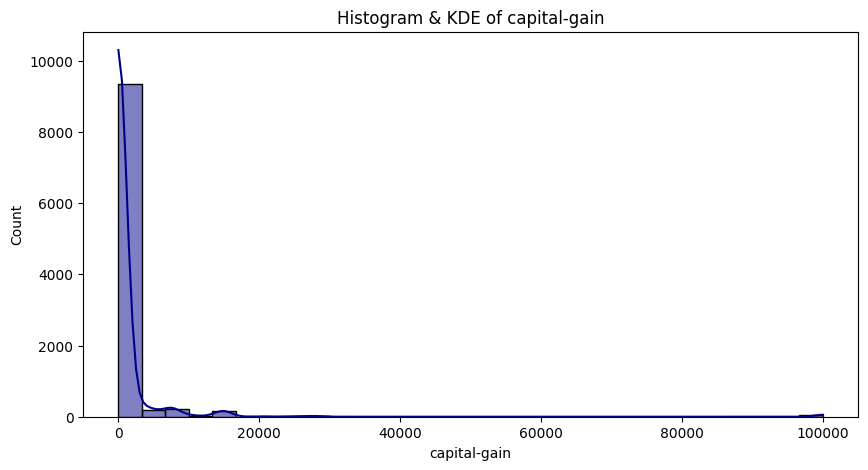

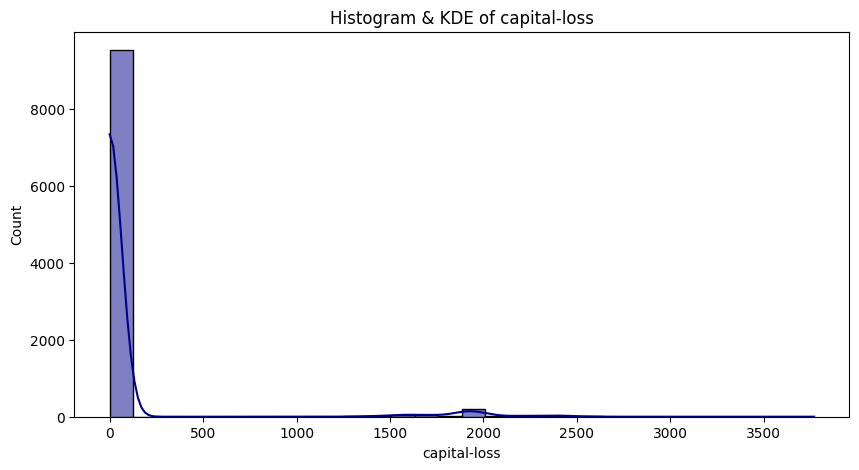

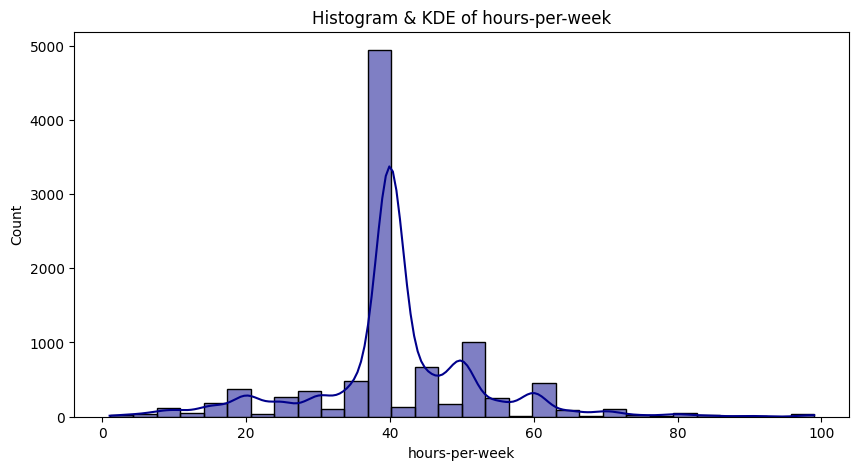

bars below


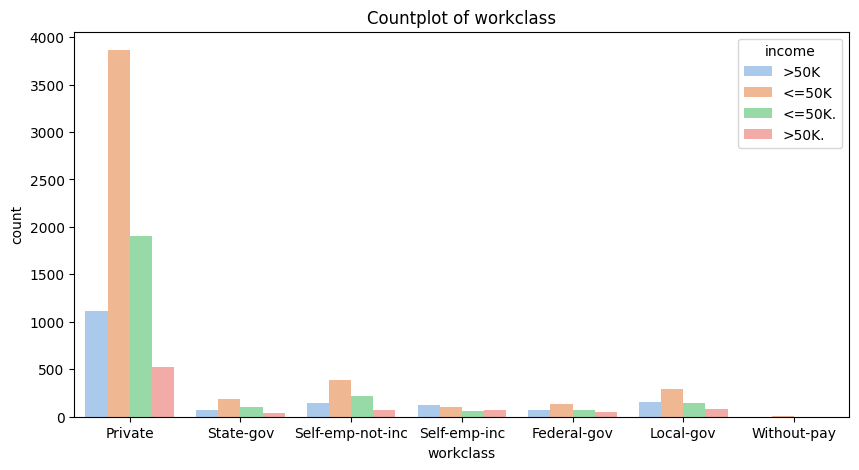

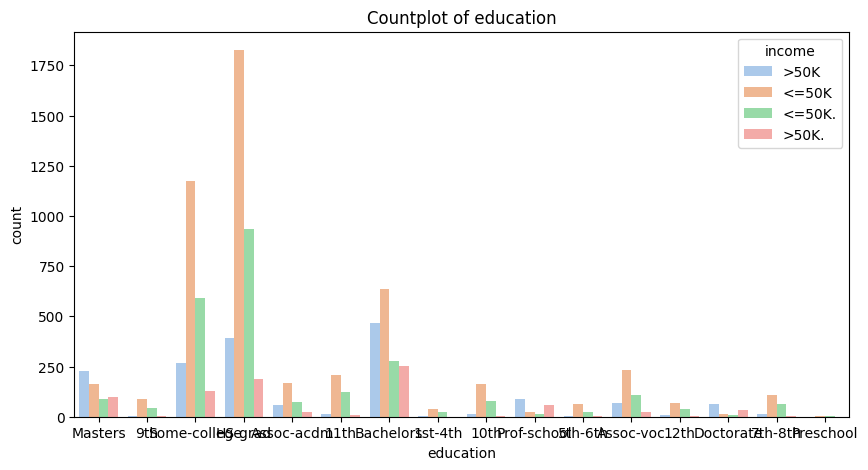

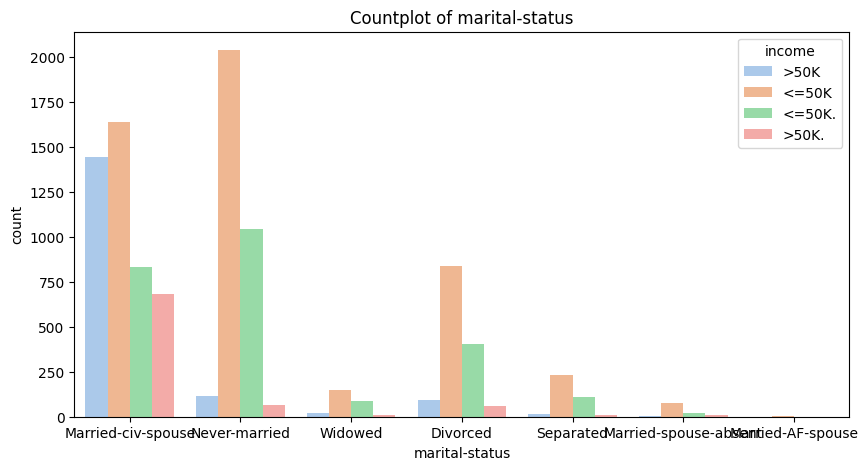

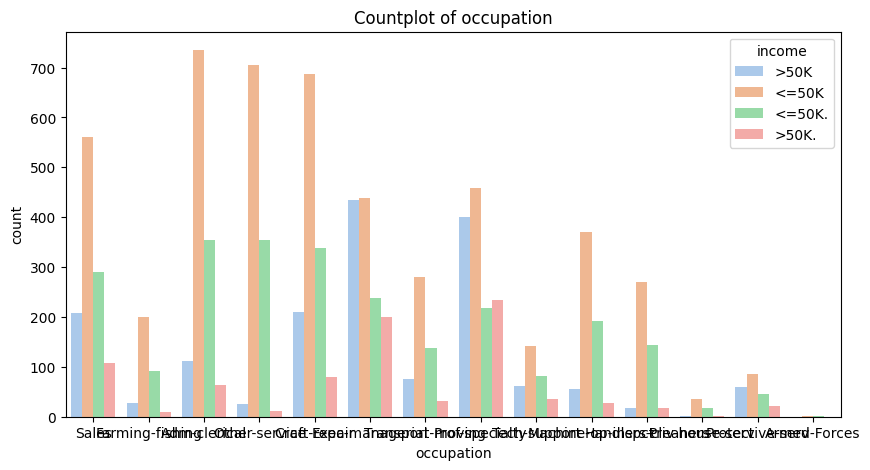

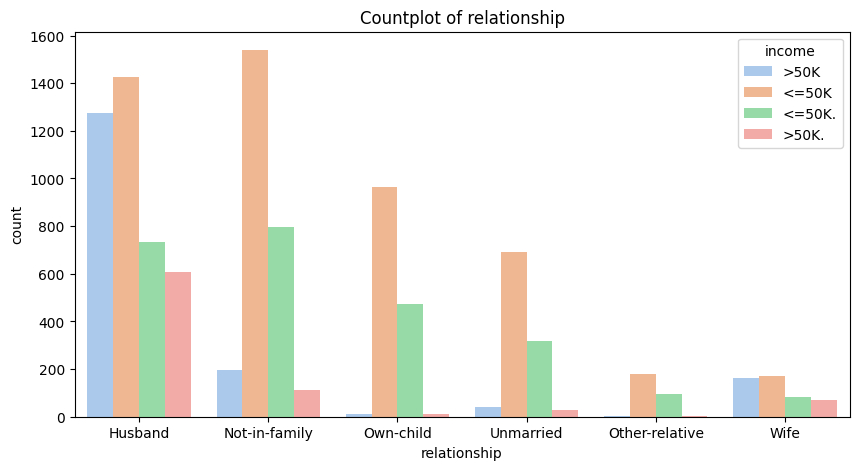

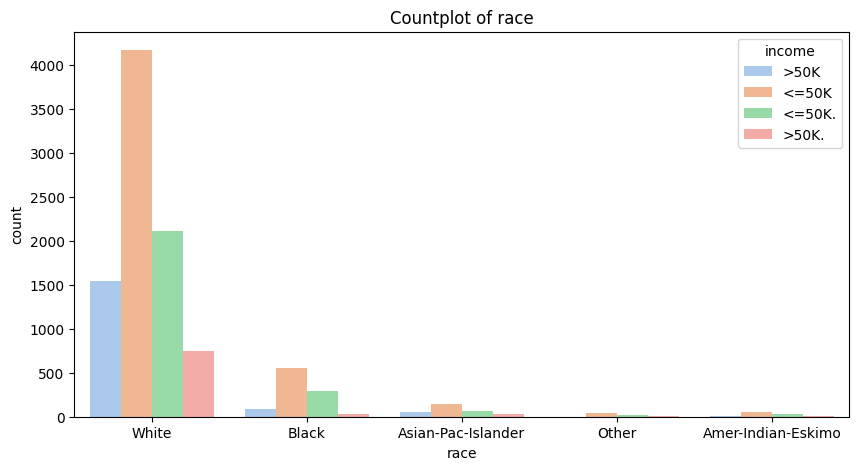

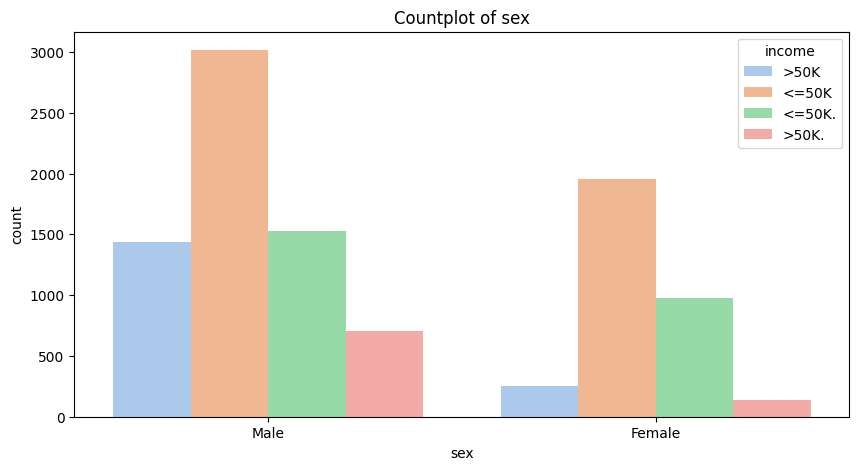

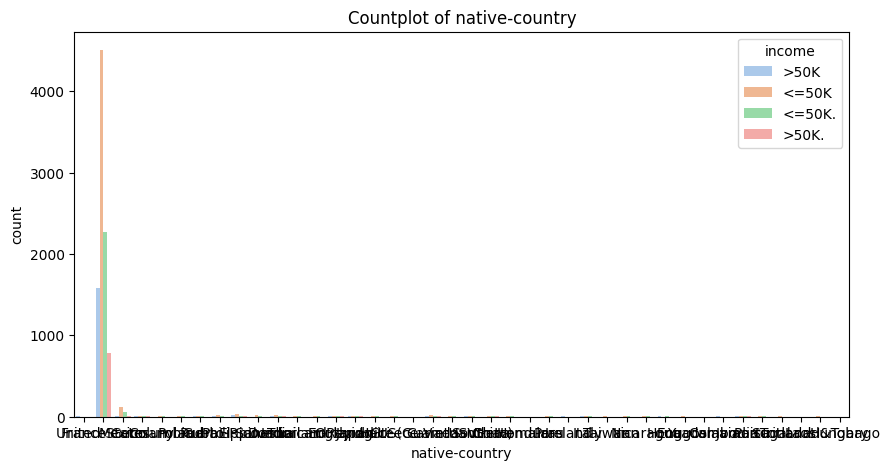

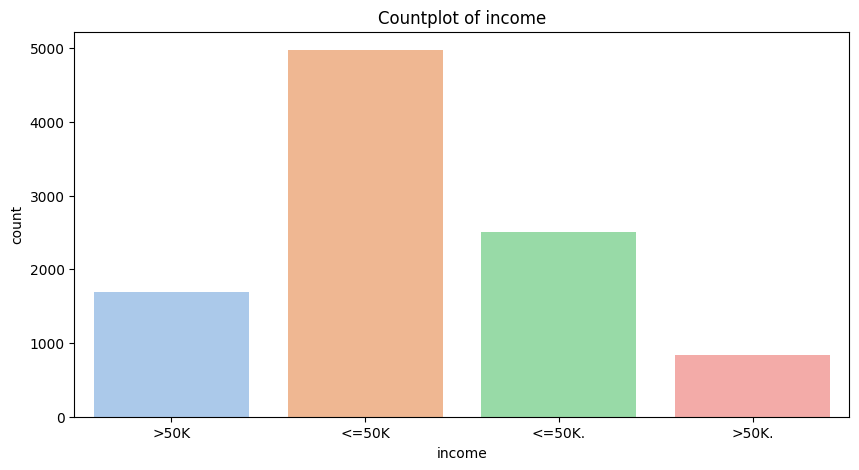

In [5]:
print("hists+kde below")
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(exclude=['int64', 'float64']).columns
for col in numerical_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True, bins=30, color="darkblue")
    plt.title(f"Histogram & KDE of {col}")
    plt.show()

print("bars below")
for col in categorical_cols:
    plt.figure(figsize=(10,5))
    sns.countplot(x=col, hue='income', data=df, palette='pastel')
    plt.title(f"Countplot of {col}")
    plt.show()


## 3. Preprocessing
Apply only necessary preprocessing and avoid leakage by fitting transforms on train data only.

In [6]:
df['income'] = df['income'].replace('<=50K.', '<=50K')
df['income'] = df['income'].replace('>50K.', '>50K')

X = df.drop('income', axis = 1)
Y = df['income']

numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = X.select_dtypes(exclude=['float64', 'int64']).columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ], remainder='passthrough')

## 4. Model Setup
Define the model and key hyperparameters, and set random_state where available.

In [7]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=117))
])

## 5. Training
Fit on train split and keep training flow clear so outputs are easy to review.

In [8]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=117
)

scores = cross_val_score(
    pipeline, 
    X,
    Y,
    cv=skf,
    scoring='accuracy'
)
print("Training complete!")

Training complete!


## 6. Evaluation
Report labeled train and test metrics clearly and compare against acceptance threshold.

Fold accuracies: [0.8205 0.8105 0.7985 0.8205 0.8005]
Mean accuracy: 0.8100999999999999
Std deviation: 0.009414881836751864
              precision    recall  f1-score   support

       <=50K       0.88      0.87      0.87      7473
        >50K       0.62      0.64      0.63      2527

    accuracy                           0.81     10000
   macro avg       0.75      0.76      0.75     10000
weighted avg       0.81      0.81      0.81     10000



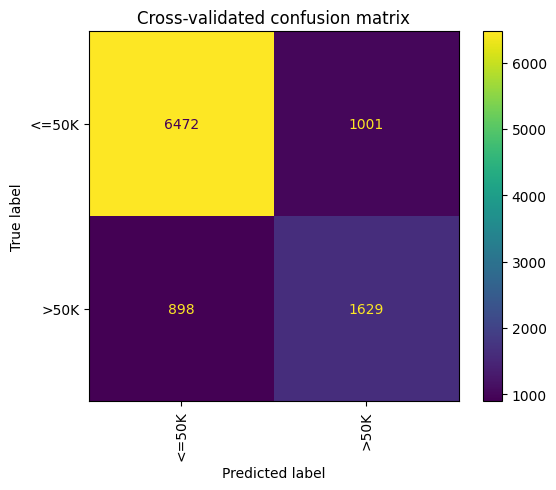

In [9]:
print("Fold accuracies:", scores)
print("Mean accuracy:", scores.mean())
print("Std deviation:", scores.std())
y_pred_cv = cross_val_predict(
    estimator=pipeline,
    X=X,
    y=Y,
    cv=skf
)
print(classification_report(Y, y_pred_cv))

cm = confusion_matrix(Y, y_pred_cv, labels=np.unique(Y))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(Y))
disp.plot(xticks_rotation='vertical')
plt.title("Cross-validated confusion matrix")
plt.show()

## 7. Interpretation
Answer only these library-training questions:
1. Which preprocessing step had the biggest impact on this model's performance?
- A decision tree classifier is most impacted by the OneHotEncoder, as it is completely neccessary to turn categorical data into something the model can actually train on.
- Other variables do not impact the model as much. For example, if we didn't use StandardScaler, no meaningful change would be apparent, as the order of the splits will remain the same.

3. What do train vs test metrics say about fit quality (underfit/overfit/good fit)?
- A default DecisionTreeClassifier should show signs of overfitting, as it splits untill we reach pure nodes, essentially memorizing the training data.
- The minority class is >50k, on which it performed poorly, getting a f1-score of 0.63.
- It performs okayish on the majority, which is to be expected as 75% of the classes are <=50k.
- Overall, this is a mediocre baseline, which can be vastly improved by utilizing models such as RandomForestClassifier.

5. Which library model/hyperparameter choice influenced results the most, based on your outputs?
- Leaving the DecisionTreeClassifier on default settings influenced the results the most. Most glaring of them all, the decision to leave max_depth without a value, as such, the model will keep splitting until it gets pure leaf nodes, which is a recipe for overfitting.